## Lazy FCA classifier interpretation

#### Read the data & split train/test & preprocess

In [32]:
import pandas

data = pandas.read_csv("churn.csv")

data = data.drop(columns = ['customerID'])
data = data[data["TotalCharges"] != ' ']
data["TotalCharges"] = data["TotalCharges"].astype(float)

cols_to_replace = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
data[cols_to_replace] = data[cols_to_replace].replace(['No phone service', 'No internet service'], 'No')

data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [33]:
import sklearn.model_selection

X = data.drop(columns = ["Churn"])
y = (data["Churn"] == "Yes").to_numpy()

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6328, 19), (704, 19), (6328,), (704,))

In [34]:
import sklearn.compose
import sklearn.preprocessing

numeric = [ "tenure", "MonthlyCharges", "TotalCharges" ]
categorical = list(set(X_train.columns) - set(numeric))

ct = sklearn.compose.ColumnTransformer(
    transformers = [
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(dtype = 'bool'), categorical)
    ]
)
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6328, 39), (704, 39), (6328,), (704,))

In [35]:
X_train = pandas.DataFrame(X_train.copy(), columns = ct.get_feature_names_out())
X_test = pandas.DataFrame(X_test.copy(), columns = ct.get_feature_names_out())

categorical = [ feature for feature in ct.get_feature_names_out() if feature.startswith("categorical__") ]
X_train[categorical] = X_train[categorical].astype(bool)
X_test[categorical] = X_test[categorical].astype(bool)

X_train

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__Dependents_No,categorical__Dependents_Yes,categorical__TechSupport_No,categorical__TechSupport_Yes,categorical__MultipleLines_No,categorical__MultipleLines_Yes,categorical__PaperlessBilling_No,...,categorical__Contract_Two year,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__StreamingMovies_No,categorical__StreamingMovies_Yes
0,3.0,55.80,154.55,True,False,False,True,True,False,False,...,False,False,False,False,True,True,False,False,True,False
1,10.0,19.80,198.25,True,False,True,False,True,False,False,...,False,False,False,False,True,False,False,True,True,False
2,49.0,106.65,5168.10,True,False,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True
3,46.0,94.90,4422.95,True,False,True,False,False,True,False,...,False,False,True,False,False,False,True,False,True,False
4,10.0,19.95,187.75,True,False,True,False,True,False,False,...,False,True,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,36.0,92.90,3379.25,False,True,False,True,False,True,False,...,True,False,True,False,False,True,False,False,False,True
6324,10.0,65.90,660.05,False,True,True,False,True,False,False,...,False,False,False,False,True,True,False,False,False,True
6325,27.0,75.50,1893.95,True,False,True,False,False,True,False,...,False,False,False,True,False,False,True,False,True,False
6326,21.0,28.50,629.35,True,False,True,False,True,False,True,...,False,False,False,True,False,True,False,False,True,False


In [36]:
y_train = pandas.Series(y_train)
y_test = pandas.Series(y_test)

y_train

0       False
1       False
2       False
3       False
4       False
        ...  
6323    False
6324    False
6325     True
6326    False
6327     True
Length: 6328, dtype: bool

#### Classifier

In [37]:
import os
import math
import tqdm
import numpy
import typing
import joblib
import matplotlib.pyplot as plt

class Hypothesis:
    def __init__(
        self,
        bool_columns: typing.List[str],
        numeric_columns: typing.List[str],
        bin_int: numpy.ndarray,
        num_int_min: numpy.ndarray,
        num_int_max: numpy.ndarray
    ):
        assert len(bin_int) == len(bool_columns)
        assert len(num_int_min) == len(numeric_columns)
        assert len(num_int_max) == len(numeric_columns)

        self.bin_int = bin_int
        self.num_int_min = num_int_min
        self.num_int_max = num_int_max
        self.bool_columns = numpy.array(bool_columns)
        self.numeric_columns = numpy.array(numeric_columns)

    def is_more_general_than(self, other, only_bin: bool = False):
        if only_bin:
            if (self.bin_int == other.bin_int).all():
                return False
            if (self.bin_int & ~other.bin_int).any():
                return False
            return True
        else:
            if self == other:
                return False
            if (self.bin_int & ~other.bin_int).any():
                return False
            if (self.num_int_min > other.num_int_min).any():
                return False
            if (self.num_int_max < other.num_int_max).any():
                return False
            return True

    def __eq__(self, other):
        assert (self.bool_columns == other.bool_columns).all()
        assert (self.numeric_columns == other.numeric_columns).all()
        return (
            (self.bin_int == other.bin_int).all() and
            (self.num_int_min == other.num_int_min).all() and
            (self.num_int_max == other.num_int_max).all()
        )

    def __hash__(self):
        return tuple([ *self.bin_int, *self.num_int_min, *self.num_int_max ]).__hash__()
    
    def clone(self):
        return Hypothesis(
            bool_columns = self.bool_columns,
            numeric_columns = self.numeric_columns,
            bin_int = self.bin_int,
            num_int_min = self.num_int_min,
            num_int_max = self.num_int_max
        )
    
    def to_dict(self):
        result = {}
        for feature, value in zip(self.bool_columns, self.bin_int):
            result[feature] = 'x' if value else ' '
        for feature, min_value, max_value in zip(self.numeric_columns, self.num_int_min, self.num_int_max):
            result[feature] = f'[{min_value}; {max_value}]'
        return result
    
class Classifiers:
    def __init__(self, hypotheses: typing.List[Hypothesis]):
        self.hypotheses = hypotheses

        self.hypotheses_map = {}
        for hypothesis in self.hypotheses:
            self.hypotheses_map[hypothesis] = self.hypotheses_map.get(hypothesis, 0) + 1

    def minimal_hypotheses(self):
        result: typing.List[Hypothesis] = []
        for key in self.hypotheses:
            for key2 in result:
                if (key.bin_int == key2.bin_int).all():
                    break
            else:
                for key2 in self.hypotheses:
                    if key2.is_more_general_than(key, only_bin = True):
                        break
                else:
                    result.append(key.clone())

        for hypothesis in result:
            for key in self.hypotheses:
                if hypothesis.is_more_general_than(key, only_bin = True):
                    hypothesis.num_int_min = numpy.minimum(hypothesis.num_int_min, key.num_int_min)
                    hypothesis.num_int_max = numpy.maximum(hypothesis.num_int_max, key.num_int_max)
        return result
    
    def describe_hypotheses(self, hypotheses: typing.List[Hypothesis]) -> pandas.DataFrame:
        df_data = []
        for hypothesis in hypotheses:
            supported_by = 0
            for hyp in self.hypotheses:
                if hypothesis == hyp or hypothesis.is_more_general_than(hyp):
                    supported_by += 1
            df_data.append({ 'supported_by': supported_by, **hypothesis.to_dict() })
        df = pandas.DataFrame(df_data)

        to_drop = []
        for column in df.columns:
            if (df[column] == ' ').all():
                to_drop.append(column)
        return df.drop(columns = to_drop).sort_values(by = 'supported_by', ascending = False)
    
    def describe_binary_features(self):
        features = {}
        for hypothesis in self.hypotheses:
            for feature, value in zip(hypothesis.bool_columns, hypothesis.bin_int):
                if value:
                    features[feature] = features.get(feature, 0) + 1
        return pandas.DataFrame(features.items()).transpose().sort_values(axis = 1, by = 1, ascending = False)
    
    def describe_numeric_features(self):
        features = {}
        for hypothesis in self.hypotheses:
            for feature, min_value, max_value in zip(hypothesis.numeric_columns, hypothesis.num_int_min, hypothesis.num_int_max):
                features[feature] = numpy.hstack([
                    features.get(feature, numpy.array([])),
                    numpy.arange(math.floor(min_value), math.ceil(max_value) + 1, step = 1)
                ])

        fig, axes = plt.subplots(1, len(features), figsize = (5 * len(features), 5))
        for ax, (feature, data) in zip(axes, features.items()):
            ax.hist(data, bins = 50)
            ax.set_title(feature)
            ax.get_yaxis().set_ticks([])
        fig.tight_layout()
        return fig

    def describe(self, save_to_folder: typing.Optional[str] = None):
        if save_to_folder:
            os.makedirs(save_to_folder, exist_ok = True)

        minimal = self.minimal_hypotheses()
        print('Number of hypotheses: ', len(self.hypotheses))
        print('Number of unique hypotheses: ', len(self.hypotheses_map))
        print('Minimal hypotheses: ', len(minimal))

        minimal_df = self.describe_hypotheses(minimal)
        display(minimal_df)
        if save_to_folder:
            minimal_df.to_csv(f"{save_to_folder}/minimal_hypotheses.csv")

        bin_df = self.describe_binary_features()
        display(bin_df)
        if save_to_folder:
            bin_df.to_csv(f"{save_to_folder}/binary_features.csv")

        fig = self.describe_numeric_features()
        if save_to_folder:
            fig.savefig(f"{save_to_folder}/numeric_features.png")
            fig.savefig(f"{save_to_folder}/numeric_features.svg")

class LazyClassifierFCA:
    def __init__(
        self,
        min_pos_for_pos_clas: int = 0, pos_coef_for_pos_clas: float = 1,
        min_neg_for_neg_clas: int = 0, neg_coef_for_neg_clas: float = 1,
        pos_clas_coef: float = 1
    ):
        self.min_pos_for_pos_clas = min_pos_for_pos_clas
        self.pos_coef_for_pos_clas = pos_coef_for_pos_clas
        self.min_neg_for_neg_clas = min_neg_for_neg_clas
        self.neg_coef_for_neg_clas = neg_coef_for_neg_clas
        self.pos_clas_coef = pos_clas_coef

    def fit(self, X_train: pandas.DataFrame, y_train: pandas.Series):
        self.bool_columns = list(X_train.columns[X_train.dtypes == 'bool'])
        self.numeric_columns = list(X_train.columns[X_train.dtypes != 'bool'])

        self.bin_X_train_pos = X_train[y_train == 1][self.bool_columns].to_numpy().astype(bool)
        self.num_X_train_pos = X_train[y_train == 1][self.numeric_columns].to_numpy()
        self.bin_X_train_neg = X_train[y_train == 0][self.bool_columns].to_numpy().astype(bool)
        self.num_X_train_neg = X_train[y_train == 0][self.numeric_columns].to_numpy()


    def get_num_matches(
        self,
        bin_X_train: numpy.ndarray, num_X_train: numpy.ndarray,
        bin_int: numpy.ndarray, num_int_min: numpy.ndarray, num_int_max: numpy.ndarray
    ):
        bin_match = (bin_X_train | ~bin_int).all(axis = 1)
        num_match = ((num_int_min <= num_X_train) & (num_X_train <= num_int_max)).all(axis = 1)
        return (bin_match & num_match).sum()

    def find_matches_impl(self, bin_int: numpy.ndarray, num_int_min: numpy.ndarray, num_int_max: numpy.ndarray):
        num_positive = self.get_num_matches(self.bin_X_train_pos, self.num_X_train_pos, bin_int, num_int_min, num_int_max)
        num_negative = self.get_num_matches(self.bin_X_train_neg, self.num_X_train_neg, bin_int, num_int_min, num_int_max)
        return num_positive, num_negative

    def find_matches(self, sample_bin: numpy.ndarray, sample_num: numpy.ndarray, bin: numpy.ndarray, num: numpy.ndarray):
        num_stacked = numpy.vstack([ sample_num, num ])
        return self.find_matches_impl(sample_bin & bin, num_stacked.min(axis = 0), num_stacked.max(axis = 0))
    
    def get_number_of_classifiers(
        self,
        sample_bin: numpy.ndarray, sample_num: numpy.ndarray,
        bin_X_train: numpy.ndarray, num_X_train: numpy.ndarray,
        is_classifier: typing.Callable[[int, int], bool]
    ):
        num_classifiers = 0
        for bin, num in zip(bin_X_train, num_X_train):
            if is_classifier(*self.find_matches(sample_bin, sample_num, bin, num)):
                num_classifiers += 1
        return num_classifiers
    
    def is_positive_classifier(self, num_positive, num_negative):
        return self.pos_coef_for_pos_clas * num_positive > num_negative and num_positive >= self.min_pos_for_pos_clas
    
    def is_negative_classifier(self, num_positive, num_negative):
        return self.neg_coef_for_neg_clas * num_negative > num_positive and num_negative >= self.min_neg_for_neg_clas
        
    def classify_sample(self, sample: pandas.Series):
        sample_bin = sample[self.bool_columns].to_numpy().astype(bool)
        sample_num = sample[self.numeric_columns].to_numpy()

        positive_classifiers = self.get_number_of_classifiers(
            sample_bin, sample_num, self.bin_X_train_pos, self.num_X_train_pos, self.is_positive_classifier
        )
        negative_classifiers = self.get_number_of_classifiers(
            sample_bin, sample_num, self.bin_X_train_neg, self.num_X_train_neg, self.is_negative_classifier
        )

        positive_classifiers *= self.pos_clas_coef
        total = negative_classifiers + positive_classifiers
        return [ (negative_classifiers / total), (positive_classifiers / total) ]


    def get_classifiers(
        self,
        sample_bin: numpy.ndarray, sample_num: numpy.ndarray,
        bin_X_train: numpy.ndarray, num_X_train: numpy.ndarray,
        is_classifier: typing.Callable[[int, int], bool]
    ) -> typing.List[Hypothesis]:
        hypotheses = []
        for bin, num in zip(bin_X_train, num_X_train):
            if is_classifier(*self.find_matches(sample_bin, sample_num, bin, num)):
                num_stacked = numpy.vstack([ sample_num, num ])
                hypothesis = Hypothesis(
                    bool_columns = self.bool_columns,
                    numeric_columns = self.numeric_columns,
                    bin_int = sample_bin & bin,
                    num_int_min = num_stacked.min(axis = 0),
                    num_int_max = num_stacked.max(axis = 0)
                )
                hypotheses.append(hypothesis)
        return Classifiers(hypotheses = hypotheses)
    
    def explain_sample(self, sample: pandas.Series) -> typing.Tuple[Classifiers, Classifiers]:
        sample_bin = sample[self.bool_columns].to_numpy().astype(bool)
        sample_num = sample[self.numeric_columns].to_numpy()

        positive_classifiers = self.get_classifiers(
            sample_bin, sample_num, self.bin_X_train_pos, self.num_X_train_pos, self.is_positive_classifier
        )
        negative_classifiers = self.get_classifiers(
            sample_bin, sample_num, self.bin_X_train_neg, self.num_X_train_neg, self.is_negative_classifier
        )
        return negative_classifiers, positive_classifiers

    def predict(self, X_test: pandas.DataFrame):
        return numpy.array(
            joblib.Parallel(n_jobs = -1)(
                joblib.delayed(self.classify_sample)(sample)
                for _, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test))
            )
        )

In [38]:
classifier = LazyClassifierFCA(
    min_pos_for_pos_clas = 5,
    pos_coef_for_pos_clas = 2.75,
    min_neg_for_neg_clas = 10,
    neg_coef_for_neg_clas = 0.25,
    pos_clas_coef = 1.0
)
classifier.fit(X_train, y_train)

In [8]:
y_pred = classifier.predict(X_test)

from utils import estimate_quality
estimate_quality(y_pred, y_test) # Ensure we did not break anything

100%|██████████| 704/704 [06:25<00:00,  1.82it/s]


{'Accuracy': 0.7556818181818182,
 'Precision': 0.5265017667844523,
 'Recall': 0.7967914438502673,
 'AUC-ROC': 0.8240724459293125,
 'F1-score': 0.6340425531914894,
 'True Positive': 149,
 'True Negative': 383,
 'False Positive': 134,
 'False Negative': 38,
 'True Negative Rate (Specificity)': 0.7408123791102514,
 'Negative Predictive Value': 0.9097387173396675,
 'False Positive Rate': 0.25918762088974856,
 'False Discovery Rate': 0.4734982332155477}

In [9]:
pandas.DataFrame(numpy.hstack([ y_pred, y_test.to_numpy().reshape(-1, 1) ])).sort_values(by = 0)

,0,1,2
147,0.004125,0.995875,1.0
660,0.049242,0.950758,1.0
328,0.064710,0.935290,1.0
562,0.065435,0.934565,0.0
264,0.067138,0.932862,1.0
...,...,...,...
513,0.995094,0.004906,0.0
88,0.995976,0.004024,0.0
370,0.996684,0.003316,0.0
459,0.996709,0.003291,0.0


#### Hugely positive object

In [41]:
neg_classifiers, pos_classifiers = classifier.explain_sample(X_test.iloc[328])

Number of hypotheses:  86
Number of unique hypotheses:  86
Minimal hypotheses:  5


,supported_by,categorical__Dependents_No,categorical__TechSupport_No,categorical__MultipleLines_Yes,categorical__PaperlessBilling_Yes,categorical__OnlineSecurity_No,categorical__OnlineBackup_No,categorical__PhoneService_Yes,categorical__DeviceProtection_No,categorical__StreamingTV_Yes,categorical__gender_Female,categorical__Contract_Month-to-month,categorical__InternetService_Fiber optic,categorical__StreamingMovies_Yes,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges
0,77,,x,,,x,x,x,x,,,,,,[16.0; 72.0],[18.8; 96.4],[279.2; 1874.3]
4,6,,,,,,,,,x,x,,,x,[16.0; 72.0],[59.55; 96.4],[1581.2; 6520.8]
1,1,x,x,,x,,x,x,x,x,x,,,,[16.0; 35.0],[62.15; 96.4],[1581.2; 2215.45]
2,1,,,,,x,x,x,,,,x,,,[16.0; 31.0],[54.35; 96.4],[1581.2; 1647.0]
3,1,,,x,x,,,x,,,x,,x,,[16.0; 71.0],[95.15; 96.4],[1581.2; 6770.85]


,5,6,1,4,7,8,0,2,10,9,12,3,11,13
0,categorical__OnlineBackup_No,categorical__PhoneService_Yes,categorical__TechSupport_No,categorical__OnlineSecurity_No,categorical__DeviceProtection_No,categorical__gender_Female,categorical__Dependents_No,categorical__MultipleLines_Yes,categorical__Partner_No,categorical__StreamingTV_Yes,categorical__StreamingMovies_Yes,categorical__PaperlessBilling_Yes,categorical__Contract_Month-to-month,categorical__InternetService_Fiber optic
1,82,81,78,78,78,41,27,24,16,7,6,5,1,1


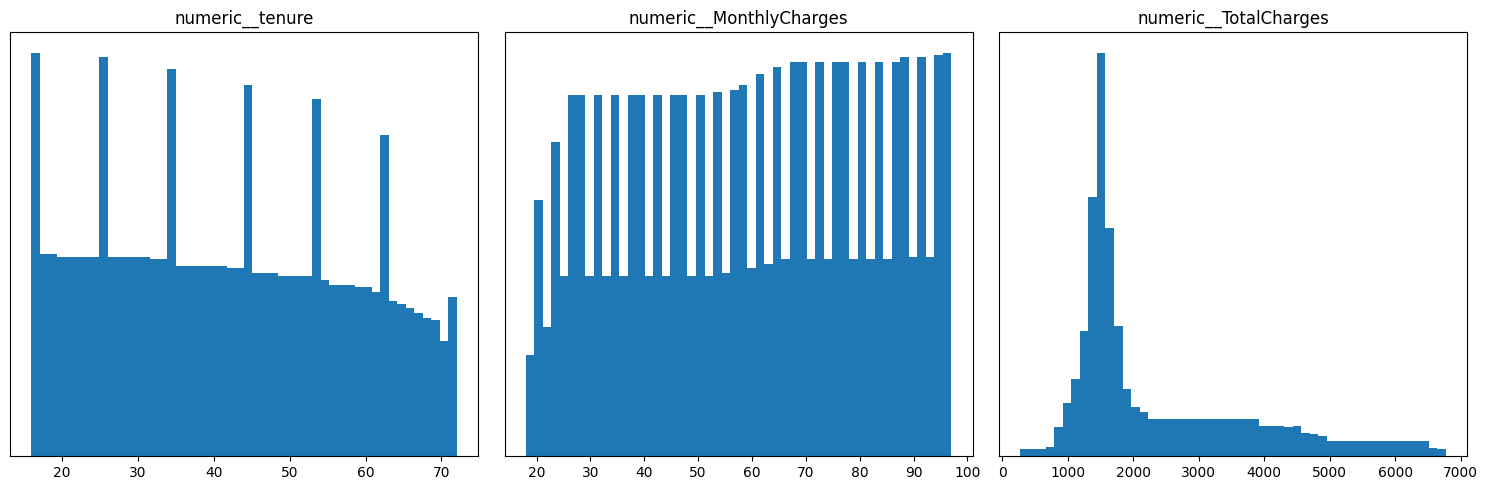

In [42]:
neg_classifiers.describe("positive_object/negative_classifiers")

Number of hypotheses:  1243
Number of unique hypotheses:  1232
Minimal hypotheses:  34


,supported_by,categorical__Dependents_No,categorical__TechSupport_No,categorical__MultipleLines_Yes,categorical__PaperlessBilling_Yes,categorical__OnlineSecurity_No,categorical__OnlineBackup_No,categorical__Partner_No,categorical__PhoneService_Yes,categorical__DeviceProtection_No,categorical__SeniorCitizen_1,categorical__StreamingTV_Yes,categorical__gender_Female,categorical__Contract_Month-to-month,categorical__PaymentMethod_Electronic check,categorical__InternetService_Fiber optic,categorical__StreamingMovies_Yes,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges
20,965,,x,,,,,,,,,,,x,,,,[1.0; 71.0],[18.95; 113.2],[19.1; 7548.1]
5,808,,,,,,,,x,x,,,,,,,,[1.0; 71.0],[18.95; 111.25],[19.1; 7548.1]
7,763,x,x,,,,,,x,,,,,,,,,[1.0; 72.0],[18.95; 113.2],[19.1; 7689.95]
11,696,,,,,,x,,,x,,,,x,,,,[1.0; 61.0],[18.95; 103.35],[19.1; 5574.75]
6,554,x,,,,,x,x,,,,,,x,,,,[1.0; 53.0],[18.95; 105.2],[19.1; 4517.25]
1,518,x,x,,,x,x,,,x,,,,,,,,[1.0; 59.0],[18.95; 96.4],[19.1; 5574.75]
3,491,x,,,x,,,x,,,,,,x,,,,[1.0; 67.0],[18.95; 114.5],[19.1; 6941.2]
14,463,,,,,,,,x,,,,x,x,,,,[1.0; 69.0],[19.0; 117.45],[19.1; 7446.9]
23,403,x,x,,x,,,,,,,,,,x,,,[1.0; 72.0],[19.45; 113.2],[19.45; 7299.65]
33,322,x,,,,x,,,,x,,,x,,,,,[1.0; 68.0],[19.1; 101.1],[19.1; 6127.6]


,6,8,4,1,0,13,5,3,10,9,12,7,2,11,15,14
0,categorical__PhoneService_Yes,categorical__Contract_Month-to-month,categorical__OnlineSecurity_No,categorical__TechSupport_No,categorical__Dependents_No,categorical__DeviceProtection_No,categorical__OnlineBackup_No,categorical__PaperlessBilling_Yes,categorical__Partner_No,categorical__InternetService_Fiber optic,categorical__PaymentMethod_Electronic check,categorical__gender_Female,categorical__MultipleLines_Yes,categorical__StreamingTV_Yes,categorical__StreamingMovies_Yes,categorical__SeniorCitizen_1
1,1113,1086,1051,1042,1014,906,901,891,805,781,678,576,476,426,425,246


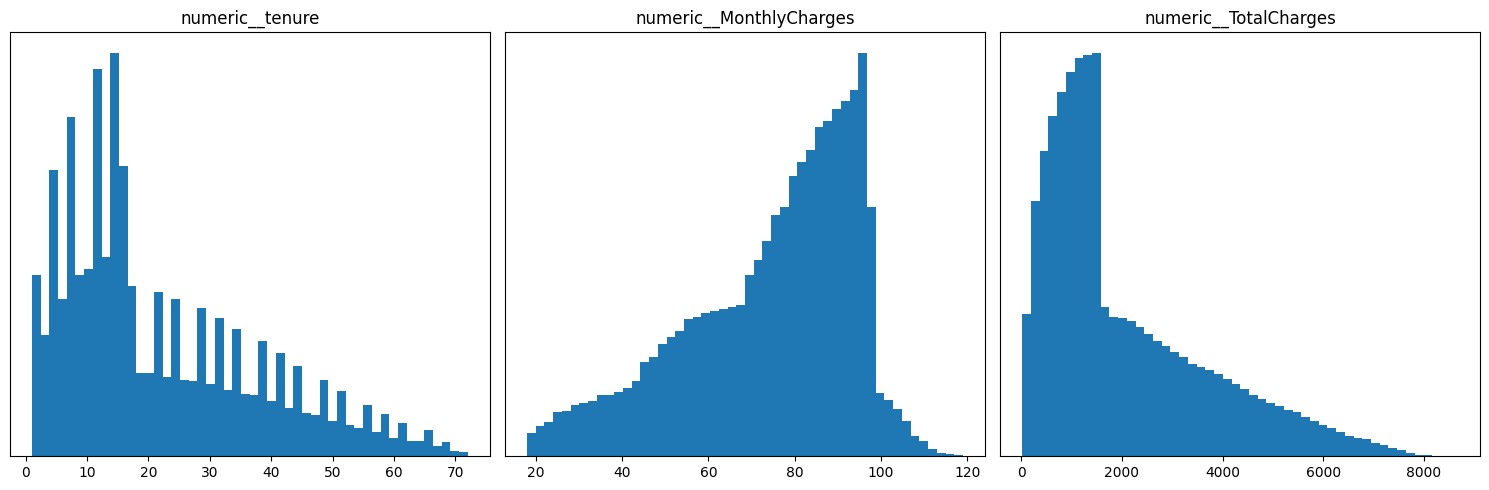

In [43]:
pos_classifiers.describe("positive_object/positive_classifiers")

#### Hugely negative object

In [44]:
neg_classifiers, pos_classifiers = classifier.explain_sample(X_test.iloc[502])

Number of hypotheses:  3545
Number of unique hypotheses:  3532
Minimal hypotheses:  30


,supported_by,categorical__Dependents_Yes,categorical__TechSupport_No,categorical__MultipleLines_No,categorical__PaperlessBilling_No,categorical__OnlineSecurity_No,categorical__OnlineBackup_No,categorical__Partner_Yes,categorical__PhoneService_Yes,categorical__DeviceProtection_No,categorical__SeniorCitizen_0,categorical__StreamingTV_No,categorical__gender_Female,categorical__Contract_Two year,categorical__PaymentMethod_Bank transfer (automatic),categorical__StreamingMovies_No,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges
20,2831,,,,,,,,x,,x,,,,,,[1.0; 72.0],[18.55; 118.75],[18.8; 8672.45]
3,2252,,,,,x,,,x,,,,,,,,[1.0; 72.0],[18.55; 114.1],[18.8; 8041.65]
4,1584,,,,,,,x,x,,,,,,,,[1.0; 72.0],[18.8; 118.75],[18.8; 8672.45]
27,1480,,x,,,,,,x,x,,x,,,,,[1.0; 72.0],[18.55; 96.85],[18.8; 6921.7]
8,1339,,,x,,,,,,,x,,,,,x,[1.0; 72.0],[18.55; 95.65],[18.8; 5817.0]
7,1252,,x,x,,,,,,x,,,,,,,[1.0; 72.0],[18.55; 100.9],[18.8; 6603.8]
28,1231,,x,x,,x,,,,,,,,,,,[1.0; 72.0],[18.55; 101.3],[18.8; 5867.0]
16,1220,,,x,,x,x,,,,,,,,,,[1.0; 72.0],[18.55; 103.1],[18.8; 5817.7]
13,1130,,,x,,x,,,,x,,x,,,,,[1.0; 72.0],[18.55; 89.6],[18.8; 4003.85]
15,1123,,x,x,,,x,,,,x,,,,,,[1.0; 72.0],[18.55; 100.45],[18.8; 5276.1]


,4,5,1,8,9,6,2,7,0,3,10,14,13,11,15,12
0,categorical__PhoneService_Yes,categorical__SeniorCitizen_0,categorical__OnlineSecurity_No,categorical__TechSupport_No,categorical__DeviceProtection_No,categorical__StreamingTV_No,categorical__OnlineBackup_No,categorical__StreamingMovies_No,categorical__MultipleLines_No,categorical__Partner_Yes,categorical__gender_Female,categorical__PaperlessBilling_No,categorical__Dependents_Yes,categorical__InternetService_No,categorical__Contract_Two year,categorical__PaymentMethod_Bank transfer (auto...
1,3284,3057,2413,2385,2300,2235,2233,2207,1814,1677,1656,1537,1049,942,927,701


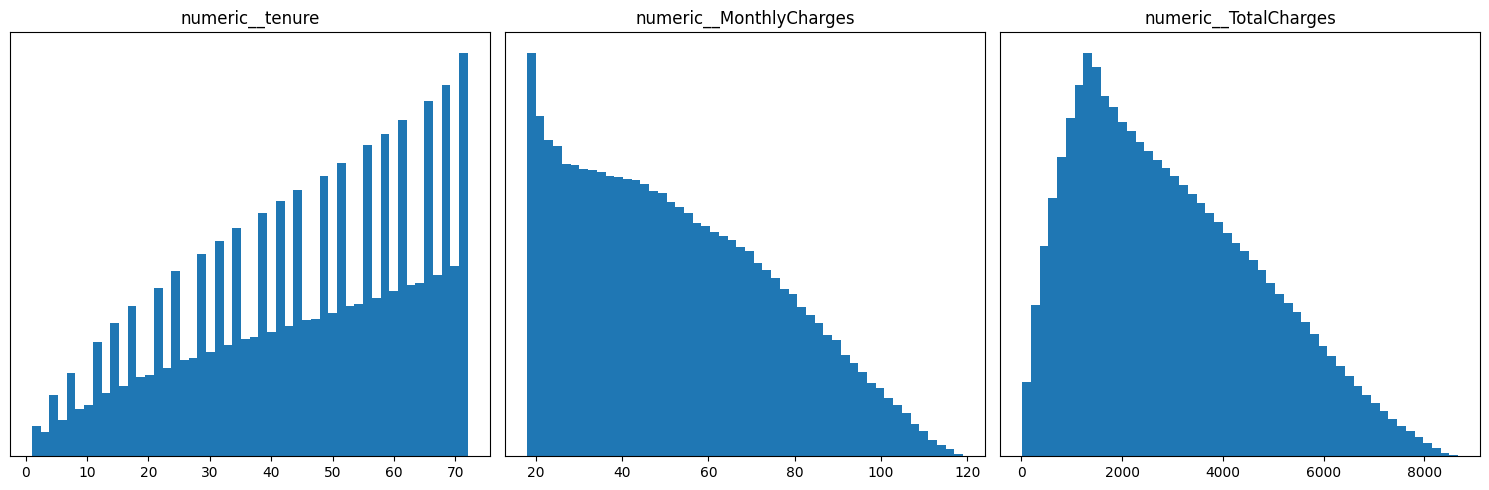

In [45]:
neg_classifiers.describe("negative_object/negative_classifiers")

Number of hypotheses:  7
Number of unique hypotheses:  7
Minimal hypotheses:  3


,supported_by,categorical__Dependents_Yes,categorical__TechSupport_No,categorical__MultipleLines_No,categorical__OnlineSecurity_No,categorical__OnlineBackup_No,categorical__Partner_Yes,categorical__PhoneService_Yes,categorical__SeniorCitizen_0,categorical__gender_Female,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges
1,5,,x,,x,,,x,,,[3.0; 72.0],[19.55; 105.0],[294.45; 2755.35]
0,1,x,,x,x,,x,x,x,x,[21.0; 72.0],[19.55; 102.8],[1463.45; 2110.15]
2,1,,x,x,,x,x,x,,x,[27.0; 72.0],[19.55; 101.25],[1463.45; 2754.45]


,4,1,2,7,3,5,6,0,8,9
0,categorical__PhoneService_Yes,categorical__MultipleLines_No,categorical__OnlineSecurity_No,categorical__TechSupport_No,categorical__Partner_Yes,categorical__SeniorCitizen_0,categorical__gender_Female,categorical__Dependents_Yes,categorical__DeviceProtection_No,categorical__OnlineBackup_No
1,7,6,6,6,4,4,4,2,2,2


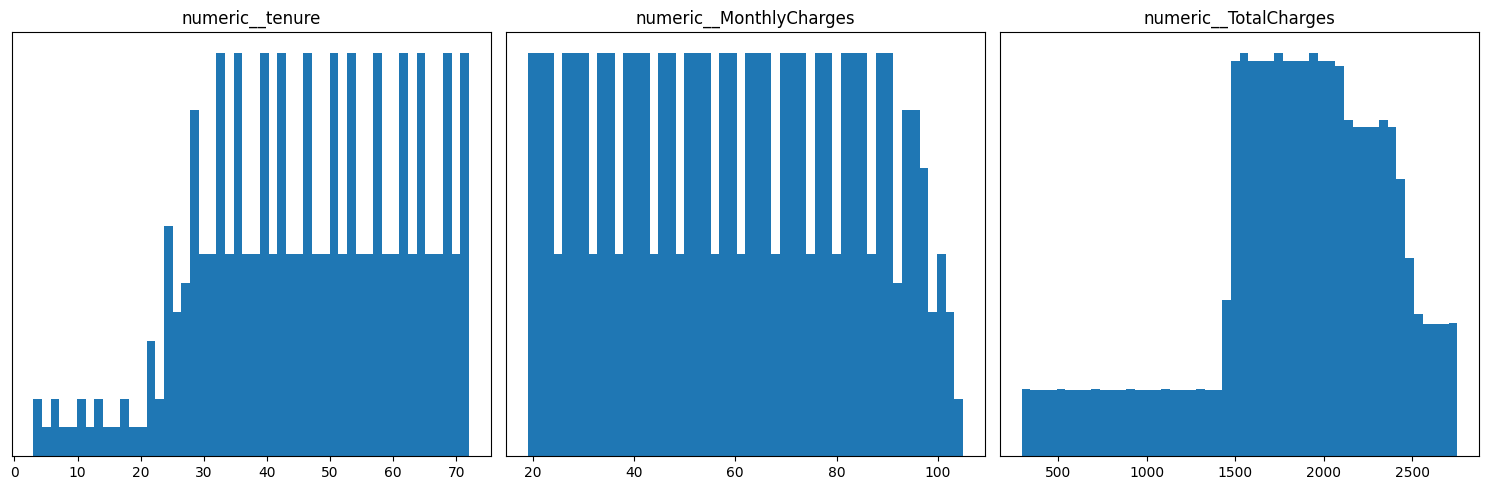

In [46]:
pos_classifiers.describe("negative_object/positive_classifiers")

#### Neutral object

In [47]:
y_pred[597], y_test[597]

(array([0.47869565, 0.52130435]), False)

In [48]:
neg_classifiers, pos_classifiers = classifier.explain_sample(X_test.iloc[597])

Number of hypotheses:  1101
Number of unique hypotheses:  1101
Minimal hypotheses:  31


,supported_by,categorical__Dependents_No,categorical__TechSupport_Yes,categorical__MultipleLines_Yes,categorical__PaperlessBilling_Yes,categorical__OnlineSecurity_Yes,categorical__OnlineBackup_No,categorical__Partner_No,categorical__PhoneService_Yes,categorical__DeviceProtection_Yes,categorical__SeniorCitizen_1,categorical__StreamingTV_Yes,categorical__gender_Female,categorical__Contract_Month-to-month,categorical__PaymentMethod_Bank transfer (automatic),categorical__InternetService_Fiber optic,categorical__StreamingMovies_Yes,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges
0,638,,,,,,x,,x,,,,,,,,,[2.0; 72.0],[18.4; 108.95],[119.5; 7111.3]
25,429,,,,,,,,x,,,,x,,,,,[7.0; 72.0],[18.4; 118.75],[159.35; 8672.45]
15,284,,,,,x,,,x,,,,,,,,,[2.0; 72.0],[48.6; 118.75],[119.5; 8672.45]
29,276,x,,,,,,x,,,,,,,,,,[2.0; 72.0],[18.7; 118.2],[119.5; 8547.15]
19,257,,x,,,x,,,,,,,,,,,,[2.0; 72.0],[33.15; 118.75],[130.5; 8672.45]
12,221,,,,,x,,,,x,,,,,,,,[2.0; 72.0],[33.6; 118.75],[119.5; 8672.45]
1,210,,,,,,,,x,x,,,,,,,,[2.0; 72.0],[50.3; 118.75],[119.5; 8672.45]
3,141,,,,,x,,,,,,x,,,,,,[7.0; 72.0],[40.65; 118.75],[477.05; 8672.45]
28,123,,,,x,,,,,x,,,,,,,,[5.0; 72.0],[35.2; 118.75],[274.35; 8672.45]
13,121,,x,x,,,,,x,,,,,,,,,[5.0; 72.0],[54.6; 118.75],[316.9; 8672.45]


,4,3,5,0,7,6,2,8,9,1,12,11,10,14,13,15
0,categorical__PhoneService_Yes,categorical__OnlineBackup_No,categorical__gender_Female,categorical__Dependents_No,categorical__OnlineSecurity_Yes,categorical__TechSupport_Yes,categorical__PaperlessBilling_Yes,categorical__Partner_No,categorical__DeviceProtection_Yes,categorical__MultipleLines_Yes,categorical__PaymentMethod_Bank transfer (auto...,categorical__StreamingMovies_Yes,categorical__StreamingTV_Yes,categorical__InternetService_Fiber optic,categorical__Contract_Month-to-month,categorical__SeniorCitizen_1
1,948,709,502,499,393,388,348,337,310,290,285,228,224,79,72,11


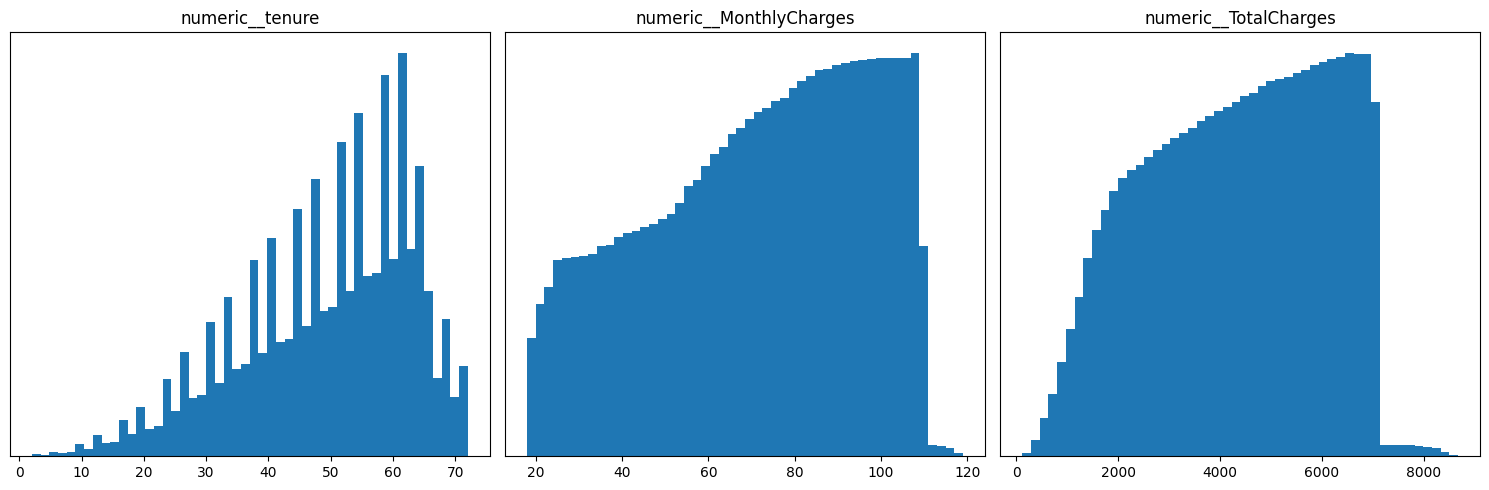

In [49]:
neg_classifiers.describe("neutral_object/negative_classifiers")

Number of hypotheses:  1199
Number of unique hypotheses:  1189
Minimal hypotheses:  16


,supported_by,categorical__Dependents_No,categorical__TechSupport_Yes,categorical__MultipleLines_Yes,categorical__PaperlessBilling_Yes,categorical__OnlineSecurity_Yes,categorical__OnlineBackup_No,categorical__Partner_No,categorical__PhoneService_Yes,categorical__DeviceProtection_Yes,categorical__StreamingTV_Yes,categorical__gender_Female,categorical__Contract_Month-to-month,categorical__PaymentMethod_Bank transfer (automatic),categorical__InternetService_Fiber optic,categorical__StreamingMovies_Yes,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges
10,1163,,,,,,,,,,,,x,,,,[1.0; 64.0],[18.95; 108.95],[19.1; 7111.3]
9,562,x,,,,,x,x,x,,,,,,,,[1.0; 64.0],[18.95; 108.95],[19.1; 7111.3]
2,296,,,,x,,x,,x,,,x,,,,,[1.0; 64.0],[19.1; 108.95],[19.1; 7111.3]
1,276,,,x,x,,x,,x,,,,,,,,[1.0; 64.0],[24.05; 108.95],[24.05; 7111.3]
14,267,,,,,,x,,x,,,,,,,x,[1.0; 64.0],[53.65; 108.95],[54.75; 7111.3]
7,36,x,,x,x,,,,x,,x,x,,,x,x,[1.0; 64.0],[93.55; 108.95],[93.85; 7111.3]
5,35,x,,,x,,x,x,,,x,x,,,,x,[1.0; 64.0],[44.85; 108.95],[85.5; 7111.3]
3,30,x,,,x,,x,x,,x,x,,,,,,[1.0; 64.0],[40.15; 108.95],[84.85; 7111.3]
6,28,,,x,x,,,,x,x,x,,,,x,x,[1.0; 72.0],[98.35; 108.95],[99.75; 7372.65]
4,26,x,,,x,,,x,,x,x,,,,,x,[1.0; 64.0],[47.95; 108.95],[90.35; 7111.3]


,7,4,0,3,2,9,8,6,1,12,10,11,5,15,13,14
0,categorical__Contract_Month-to-month,categorical__PhoneService_Yes,categorical__Dependents_No,categorical__OnlineBackup_No,categorical__PaperlessBilling_Yes,categorical__Partner_No,categorical__InternetService_Fiber optic,categorical__gender_Female,categorical__MultipleLines_Yes,categorical__StreamingMovies_Yes,categorical__StreamingTV_Yes,categorical__SeniorCitizen_1,categorical__DeviceProtection_Yes,categorical__PaymentMethod_Bank transfer (auto...,categorical__TechSupport_Yes,categorical__OnlineSecurity_Yes
1,1163,1080,996,949,891,826,792,591,449,403,400,257,206,96,93,75


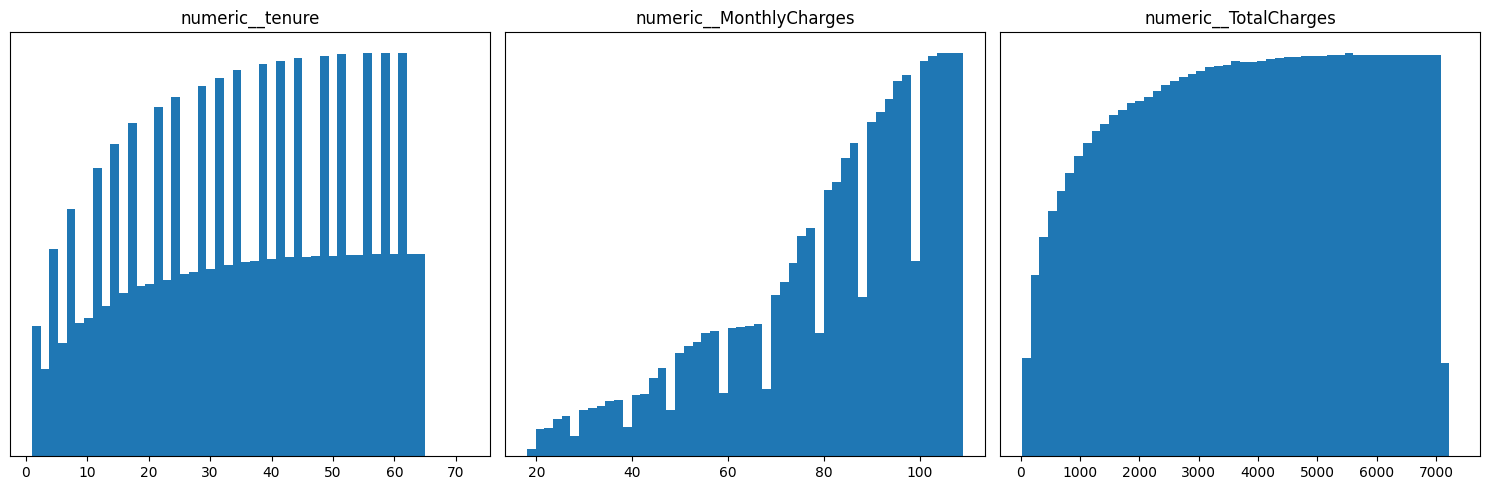

In [50]:
pos_classifiers.describe("neutral_object/positive_classifiers")

#### Explore formal concepts

In [51]:
pandas.DataFrame(classifier.bin_X_train_pos, columns = classifier.bool_columns).astype(int).to_csv("cbo/positive.csv", index = False)
pandas.DataFrame(classifier.bin_X_train_neg, columns = classifier.bool_columns).astype(int).to_csv("cbo/negative.csv", index = False)

Now run `cbo/cbo.cpp`

In [52]:
print("Negative hypotheses: ")
with open("cbo/negative_hypotheses.txt", "r") as file:
    for line in file:
        print(line.split('}')[0][2:].split(','))

Negative hypotheses: 
['categorical__InternetService_DSL']
['categorical__InternetService_No', 'categorical__OnlineSecurity_No', 'categorical__PhoneService_Yes', 'categorical__OnlineBackup_No', 'categorical__StreamingMovies_No', 'categorical__StreamingTV_No', 'categorical__TechSupport_No', 'categorical__DeviceProtection_No']
['categorical__OnlineSecurity_No', 'categorical__PhoneService_Yes', 'categorical__MultipleLines_No', 'categorical__OnlineBackup_No', 'categorical__SeniorCitizen_0', 'categorical__StreamingMovies_No', 'categorical__StreamingTV_No']
['categorical__OnlineSecurity_No', 'categorical__PhoneService_Yes', 'categorical__MultipleLines_No', 'categorical__OnlineBackup_No', 'categorical__SeniorCitizen_0', 'categorical__StreamingTV_No', 'categorical__DeviceProtection_No']
['categorical__OnlineSecurity_No', 'categorical__PhoneService_Yes', 'categorical__MultipleLines_No', 'categorical__OnlineBackup_No', 'categorical__StreamingMovies_No', 'categorical__StreamingTV_No', 'categorica

In [53]:
print("Positive hypotheses: ")
with open("cbo/positive_hypotheses.txt", "r") as file:
    for line in file:
        print(line.split('}')[0][2:].split(','))

Positive hypotheses: 
['categorical__InternetService_Fiber optic', 'categorical__PhoneService_Yes']
['categorical__OnlineSecurity_No']
['categorical__PhoneService_Yes']
['categorical__MultipleLines_No', 'categorical__OnlineBackup_No']
['categorical__MultipleLines_No', 'categorical__Contract_Month-to-month']
['categorical__MultipleLines_No', 'categorical__PaymentMethod_Electronic check']
['categorical__MultipleLines_No', 'categorical__PaperlessBilling_Yes']
['categorical__MultipleLines_No', 'categorical__Dependents_No']
['categorical__MultipleLines_No', 'categorical__SeniorCitizen_0', 'categorical__Partner_No']
['categorical__MultipleLines_No', 'categorical__StreamingMovies_No', 'categorical__Partner_No']
['categorical__MultipleLines_No', 'categorical__Partner_No']
['categorical__MultipleLines_No', 'categorical__gender_Female', 'categorical__TechSupport_No']
['categorical__MultipleLines_No', 'categorical__TechSupport_No']
['categorical__OnlineBackup_No']
['categorical__Contract_Month-to